In [2]:
from bigraph_schema import TypeSystem
# from bigraph_viz.diagram import plot_bigraph as plt_bigraph
from bigraph_viz import plot_bigraph, replace_regex_recursive

core = TypeSystem()

In [3]:
import os
current_directory = os.getcwd()
current_directory

'/Users/eranagmon/code/bigraph-viz/notebooks'

Writing out/hybrid_diagram


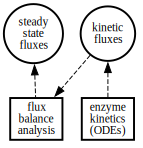

In [4]:
hybrid = {
    'flux balance analysis': {
        '_type': 'step',
        '_inputs': {
            'flux_bounds': 'array'
        },
        '_outputs': {
            'fluxes': 'array'
        },
        'inputs': {
            'flux_bounds': ['kinetic fluxes']
        },
        'outputs': {
            'fluxes': ['steady state fluxes']
        }
    },
    'enzyme kinetics (ODEs)': {
        '_type': 'process',
        '_inputs': {
            # '[substrates]': 'array',
            # '[enzymes]': 'array'
        },
        '_outputs': {
            'flux_bounds': 'array'
        },
        'inputs': {
            # '[substrates]': ['substrates'],
            # '[enzymes]': ['enzymes']
        },
        'outputs': {
            'flux_bounds': ['kinetic fluxes']
        }
    },
    'kinetic fluxes': 'array',
    'steady state fluxes': 'array',
    # 'substrates': 'array',
    # 'enzymes': 'array',
}

hybrid = replace_regex_recursive(hybrid)
plot_bigraph(
    hybrid, 
    core=core, 
    port_labels=False,
    remove_nodes= [('enzyme<br/>kinetics<br/>(ODEs)', 'interval')],
    out_dir='out',
    filename='hybrid_diagram',
)

Writing out/abm_diagram


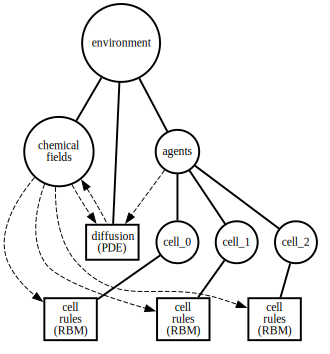

In [15]:
n_agents = 3

agent = {
    # 'internal': 'array',
    # 'external': 'array',
    'cell rules (RBM)': {
        '_type': 'process',
        '_inputs': {
            'fields': 'array',
            # 'external': 'array'
        },
        '_outputs': {
            # 'internal': 'array',
            # 'external': 'array'
        },
        'inputs': {
            'fields': ['..', '..', 'chemical fields'],
            # 'external': ['external']
        },
        'outputs': {
            # 'internal': ['internal'],
            # 'external': ['external']
        }
    }
}

abm = {
    'environment': {
        'diffusion (PDE)': {
            '_type': 'step',
            '_inputs': {
                'fields': 'array',
                'agents': 'tree[any]',
            },
            '_outputs': {
                'fields': 'array'
            },
            'inputs': {
                'fields': ['chemical fields'],
                'agents': ['agents'],
            },
            'outputs': {
                'fields': ['chemical fields']
            }
        },
        'chemical fields': 'array',
        'agents': {
            f'cell_{n}': agent for n in range(n_agents)
        }
    }
}

abm = replace_regex_recursive(abm)
plot_bigraph(
    abm, 
    core=core,
    port_labels=False,
    # remove_process_place_edges=True,
    out_dir='out',
    filename='abm_diagram',
)

In [9]:
help(plot_bigraph)

Help on function plot_bigraph in module bigraph_viz.diagram:

plot_bigraph(state, schema=None, core=None, out_dir=None, filename=None, file_format='png', size='16,10', node_label_size='12pt', show_values=False, show_types=False, port_labels=True, port_label_size='10pt', rankdir='TB', print_source=False, dpi='70', label_margin='0.05', node_border_colors=None, node_fill_colors=None, node_groups=False, remove_nodes=None, invisible_edges=False, remove_process_place_edges=False)

